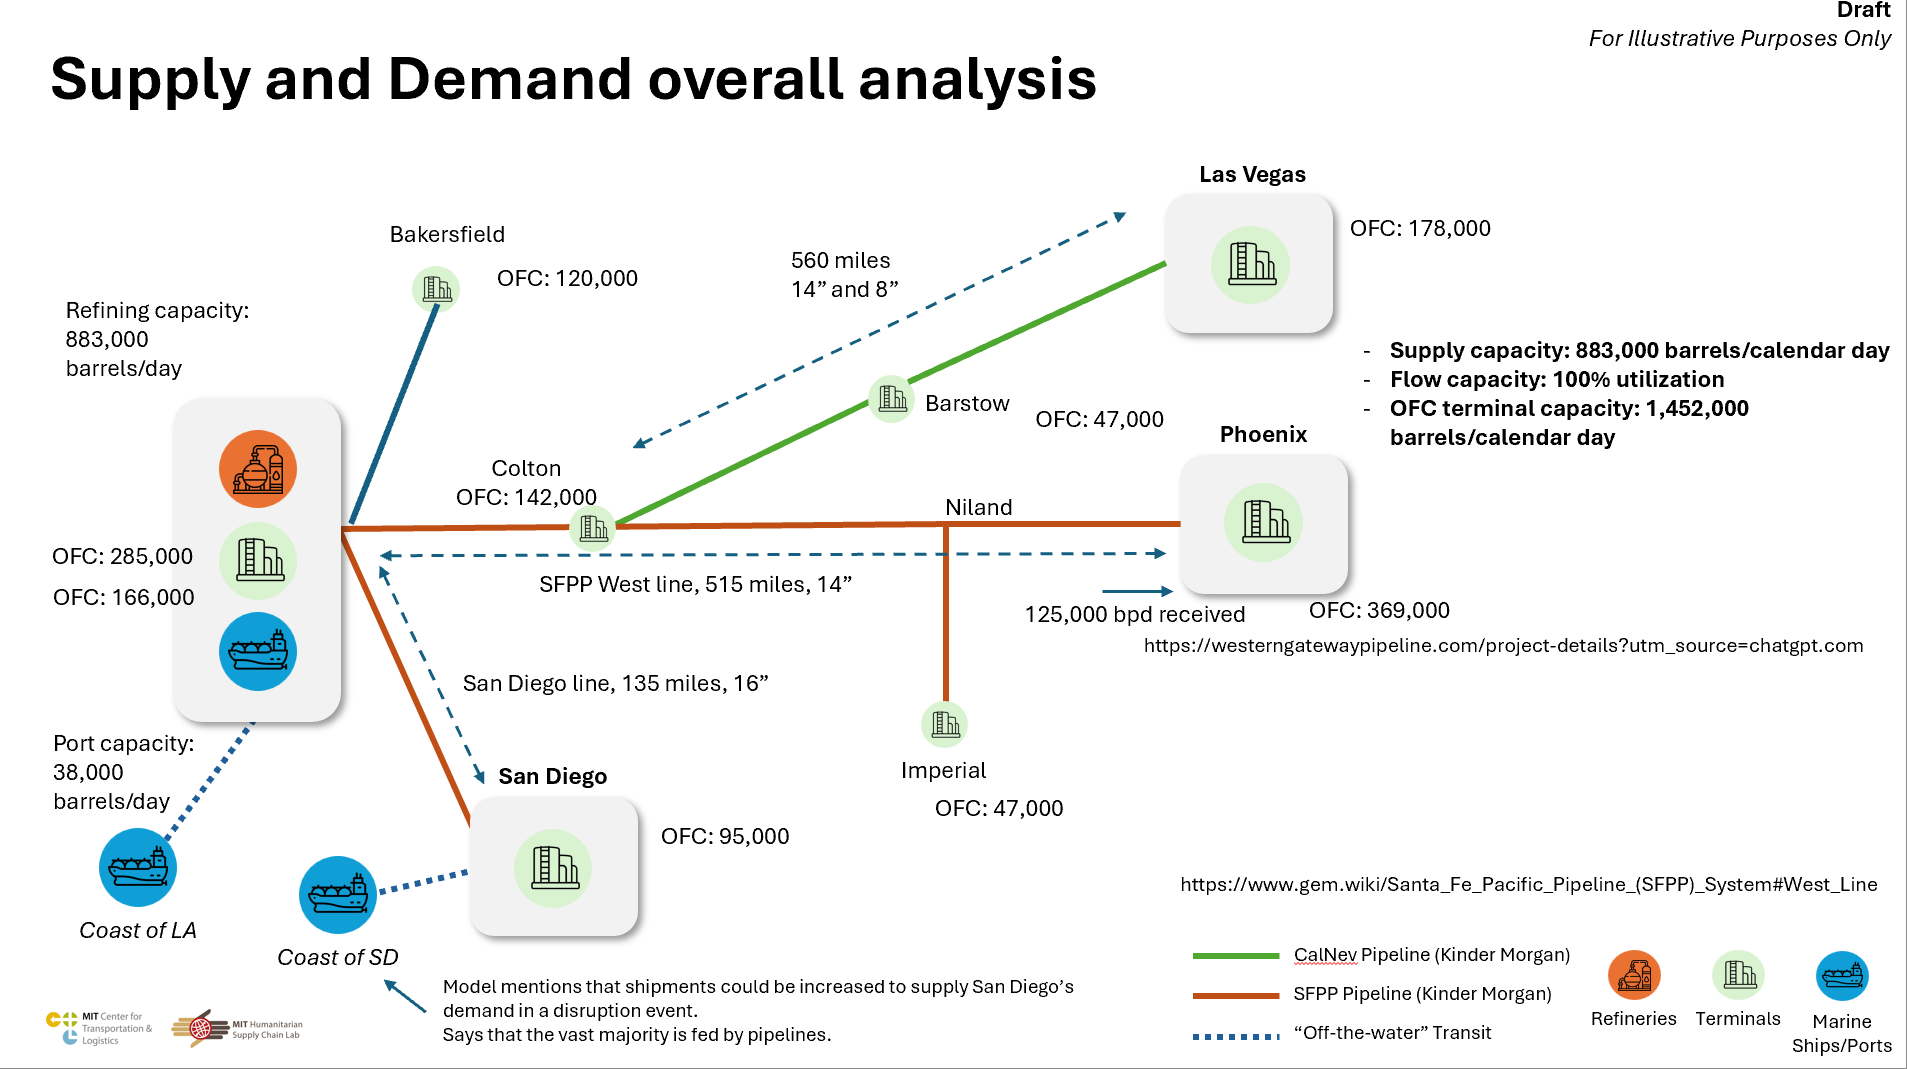

In [418]:
!pip install simpy
#Libraries
import simpy
import matplotlib
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

#Data loading

In [419]:
#Data loading
from google.colab import auth
import gspread
from google.auth import default


# 1. Authenticate to Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Open the spreadsheet by its ID

#DEFAULT INPUTS SPREADSHEET:
#spreadsheet_id = '1z4IDIkufA_rz4FbLWtfAIgxXhf7mepB73SaG2AieAEY'

#SANDIA SCENARIO INPUTS SPREADSHEET:
#spreadsheet_id = '1m9pYCGkW89eZiy8S_jz9V9JK5l1T99O4Q7PTBWpCQoE'

#EL SEGUNDO FIRE SCENARIO
#spreadsheet_id = '1a_VFZRsvcLuK8AY9wi9l5DY1YrGRoePRCasftUpc2hM'


#Supply disruption in los angeles (phillips66 case)
#1UVdtbg1IHQ3z5O8YjnntsPua79zAzaxNnEyUAPZoPAQ

spreadsheet_id = '1m9pYCGkW89eZiy8S_jz9V9JK5l1T99O4Q7PTBWpCQoE'
spreadsheet = gc.open_by_key(spreadsheet_id)

# 3. Create a dictionary to hold the DataFrames
dataframes = {}

# 4. Iterate through all sheets and create a DataFrame for each
for worksheet in spreadsheet.worksheets():
    data = worksheet.get_all_values()
    df = pd.DataFrame(data[1:], columns=data[0]) # Use first row as header
    dataframes[worksheet.title] = df
    print(f"Imported sheet: {worksheet.title}")

# Access your specific DataFrames:
df_supply = dataframes['supply']
df_supply_disruption = dataframes['supply_disruption_scenario']

df_pipeline = dataframes['pipeline_segments']
df_pipeline_disruption = dataframes['pipeline_disruption_scenario']
df_terminals = dataframes['terminals']

Imported sheet: Details
Imported sheet: supply
Imported sheet: supply_disruption_scenario
Imported sheet: pipeline_segments
Imported sheet: pipeline_disruption_scenario
Imported sheet: terminals
Imported sheet: pipeline_leadtime_estimation


In [420]:
df_supply['capacity_bbl_day'] = df_supply['capacity_bbl_day'].astype(float)
columns_to_keep = ['supply_type', 'capacity_bbl_day']
df_supply = df_supply.groupby(by='supply_type').sum().reset_index()[columns_to_keep]
df_supply

,supply_type,capacity_bbl_day
0,port,37957.0
1,refinery,830110.0


In [421]:
df_pipeline.head()

,pipeline_segment,upstream_connection,leadtime,capacity_bbl_day
0,LA_Interior,,1,293296.5
1,LA_Colton,,1,329021.175
2,Colton_Imperial,LA_Colton,3,129028.725
3,Imperial_Phoenix,Colton_Imperial,4,93118.725
4,Colton_Barstow,LA_Colton,2,95705.4


In [422]:
df_terminals.head()

,terminal_group,pipeline,initial_inventory_days,target_inventory_on_hand,default_demand_bbl_day
0,Imperial,Colton_Imperial,12,12,34200
1,San Diego,LA_SanDiego,12,12,65636
2,Phoenix,Imperial_Phoenix,12,12,88684.5
3,Los Angeles,LA_Interior,12,12,155957
4,Orange,LA_Interior,12,12,123373


In [423]:
df_supply_disruption.head()

,supply_type,day,percentage_of_capacity
0,refinery,1,0
1,refinery,2,0
2,refinery,3,0
3,refinery,4,0
4,refinery,5,0


#Simulation definition and execution

In [424]:
#Simulation
# Simulation Classes
class Refinery:
    def __init__(self, env, capacity_per_day, capacity_schedule=None):
        self.env = env
        self.capacity_per_day = float(capacity_per_day)
        self.remaining_today = 0.0
        self.injected_today = 0.0
        self.capacity_schedule = capacity_schedule or {}
        self.history = []
        self.env.process(self.daily_process())

    def daily_process(self):
        day = 0  # Strict integer counter
        while True:
            # 1. Set today's capacity based on the disruption schedule
            daily_cap = float(self.capacity_schedule.get(day, self.capacity_per_day))
            self.remaining_today = daily_cap
            self.injected_today = 0.0

            # 2. Wait until the end of the day (after Orchestrator finishes at Time .02)
            yield self.env.timeout(0.98)

            # 3. Log results AFTER injections happen
            util = (self.injected_today / daily_cap) if daily_cap > 0 else 0.0
            self.history.append({
                "day": day,
                "refinery_capacity": daily_cap,
                "refinery_injected": self.injected_today,
                "refinery_utilization": util
            })

            # 4. Snap exactly to the start of the next integer day
            day += 1
            yield self.env.timeout(day - self.env.now)

class Port:
    def __init__(self, env, capacity_per_day):
        self.env = env
        self.capacity_per_day = float(capacity_per_day)
        self.remaining_today = 0.0
        self.injected_today = 0.0
        self.history = []
        self.env.process(self.daily_process())

    def daily_process(self):
        day = 0
        while True:
            self.remaining_today = self.capacity_per_day
            self.injected_today = 0.0

            # Wait until the end of the day (after Orchestrator finishes at Time .02)
            yield self.env.timeout(0.98)

            # Log results AFTER injections happen
            util = (self.injected_today / self.capacity_per_day) if self.capacity_per_day > 0 else 0.0
            self.history.append({
                "day": day,
                "port_capacity": self.capacity_per_day,
                "port_injected": self.injected_today,
                "port_utilization": util
            })

            # Snap to the next integer day
            day += 1
            yield self.env.timeout(day - self.env.now)

class Pipeline:
    """
    Hybrid model: capacity is enforced on the day the batch reaches each segment.
    """
    def __init__(self, env, name, daily_capacity, lead_time_days, upstream=None, capacity_schedule=None):
        self.env = env
        self.name = name
        self.daily_capacity = float(daily_capacity)
        self.lead_time_days = int(lead_time_days)
        self.upstream = upstream
        self.booked_by_day = {}
        # New: Store the day-by-day actual capacity schedule
        self.capacity_schedule = capacity_schedule or {}

    def iter_chain(self):
        p = self
        while p is not None:
            yield p
            p = p.upstream

    def chain_in_physical_order(self):
        chain = list(self.iter_chain())
        chain.reverse()
        return chain

    def total_lead_time(self) -> int:
        return sum(p.lead_time_days for p in self.iter_chain())

    def cap_for_day(self, day: int) -> float:
        # Check if there is a disruption for this specific day, otherwise return normal capacity
        return float(self.capacity_schedule.get(day, self.daily_capacity))

    def booked_for_day(self, day: int) -> float:
        return float(self.booked_by_day.get(day, 0.0))

    def available_for_day(self, day: int) -> float:
        return max(0.0, self.cap_for_day(day) - self.booked_for_day(day))

    def chain_with_traverse_days(self, inject_day: int):
        segments = self.chain_in_physical_order()
        traverse_days = []
        day_cursor = int(inject_day)
        for seg in segments:
            traverse_days.append((seg, day_cursor))
            day_cursor += seg.lead_time_days
        return traverse_days

    def feasible_qty(self, qty: float) -> float:
        qty = float(qty)
        if qty <= 0: return 0.0
        inject_day = int(self.env.now)
        feasible = qty
        for seg, day in self.chain_with_traverse_days(inject_day):
            feasible = min(feasible, seg.available_for_day(day))
        return feasible

    def inject(self, qty, refinery, port, terminal):
        # ... (Leave the inject and _flow methods exactly as they were in the previous version) ...
        qty = float(qty)
        feasible = self.feasible_qty(qty)
        if feasible <= 0: return 0.0, 0.0, 0.0

        # Source logic
        from_refinery = min(refinery.remaining_today, feasible)
        refinery.remaining_today -= from_refinery
        refinery.injected_today += from_refinery

        remaining = feasible - from_refinery
        from_port = min(port.remaining_today, remaining)
        port.remaining_today -= from_port
        port.injected_today += from_port

        injected = from_refinery + from_port
        if injected <= 0: return 0.0, 0.0, 0.0

        # Book capacity
        inject_day = int(self.env.now)
        for seg, day in self.chain_with_traverse_days(inject_day):
            seg.booked_by_day[day] = seg.booked_for_day(day) + injected

        # Terminal accounting
        terminal.in_transit += injected
        terminal.inj_refinery_today += from_refinery
        terminal.inj_port_today += from_port

        self.env.process(self._flow(injected, terminal))
        return injected, from_refinery, from_port

    def _flow(self, qty, terminal):
        yield self.env.timeout(self.total_lead_time())
        terminal.receive(qty)

class PipelineLogger:
    def __init__(self, env, pipelines, rows):
        self.env = env
        self.pipelines = pipelines
        self.rows = rows
        self.env.process(self.process())

    def process(self):
        day = 0
        while True:
            # Wait until the end of the day (Time .98) AFTER the Orchestrator finishes
            yield self.env.timeout(0.98)

            for p in self.pipelines:
                cap = float(p.cap_for_day(day))
                used = float(p.booked_for_day(day))
                remaining = cap - used
                util = (used / cap) if cap > 0 else 0.0

                self.rows.append({
                    "day": day, "pipeline": p.name, "cap": cap,
                    "used_today": used, "utilization": util,
                    "remaining_end_day": remaining, "lead_time_days": int(p.lead_time_days)
                })

            # Snap to the start of the next integer day
            day += 1
            yield self.env.timeout(day - self.env.now)

class Terminal:
    def __init__(self, env, name, pipeline, refinery, port, **kwargs):
        self.env = env
        self.name = name
        self.pipeline = pipeline
        self.refinery = refinery
        self.port = port
        self.on_hand = float(kwargs.get('initial_inventory', 0))
        self.in_transit = 0.0

        self.inj_refinery_today = 0.0
        self.inj_port_today = 0.0

        self.default_demand_per_day = float(kwargs.get('default_demand_per_day', 0))
        self.target_on_hand = float(kwargs.get('target_on_hand', 0))
        self.kpi_rows = kwargs.get('kpi_rows')

        self.daily_stats = {}
        self.env.process(self.daily_loop())

    def get_demand_for_day(self, day):
        return self.default_demand_per_day

    def calculate_desired_order(self):
        lt = self.pipeline.total_lead_time()
        inv_position = self.on_hand + self.in_transit

        desired_pos = self.target_on_hand + (self.default_demand_per_day * lt)
        raw_order = max(0.0, desired_pos - inv_position)

        projected_on_hand = inv_position - (self.default_demand_per_day * lt)
        max_tank_capacity = self.target_on_hand * 1.05
        available_physical_space = max(0.0, max_tank_capacity - projected_on_hand)

        return min(raw_order, available_physical_space)

    def receive(self, qty):
        self.on_hand += qty
        self.in_transit = max(0.0, self.in_transit - qty)
        if 'received' in self.daily_stats:
            self.daily_stats['received'] += qty

    def daily_loop(self):
        day = 0  # Strict integer counter
        while True:
            self.daily_stats = {'demand': 0, 'ordered': 0, 'inj_ref': 0, 'inj_port': 0, 'received': 0, 'satisfied': 0}
            self.inj_refinery_today = 0.0
            self.inj_port_today = 0.0

            # 1. Wait for pipeline deliveries scheduled exactly at the day boundary
            yield self.env.timeout(0.01)

            # 2. Consume demand
            demand = self.get_demand_for_day(day)
            satisfied = min(self.on_hand, demand)
            self.on_hand -= satisfied

            self.daily_stats['demand'] = demand
            self.daily_stats['satisfied'] = satisfied

            # 3. Wait for the Orchestrator to inject fuel
            yield self.env.timeout(0.98)

            # 4. Log KPIs at the true End-of-Day
            self.kpi_rows.append({
                "day": day, "terminal": self.name, "demand": demand,
                "target_capacity": self.target_on_hand,
                "satisfied": self.daily_stats['satisfied'],
                "ordered": self.daily_stats['ordered'],
                "inj_refinery": self.daily_stats['inj_ref'],
                "inj_port": self.daily_stats['inj_port'],
                "received": self.daily_stats['received'],
                "on_hand_end": self.on_hand, "in_transit_end": self.in_transit
            })

            # 5. Move clock exactly to the start of the next integer day
            day += 1
            yield self.env.timeout(day - self.env.now)


class SupplyOrchestrator:
    def __init__(self, env, terminals, refinery, port):
        self.env = env
        self.terminals = terminals
        self.refinery = refinery
        self.port = port
        self.env.process(self.run_daily_allocation())

    def run_daily_allocation(self):
        day = 0
        while True:
            # Snap exactly to Day.02 to ensure it runs after Terminals consume demand
            target_time = day + 0.02
            yield self.env.timeout(target_time - self.env.now)

            # 1. Collect Desired Orders
            orders = {t: t.calculate_desired_order() for t in self.terminals}
            total_requested = sum(orders.values())

            # 2. Refinery Pass (Pro-rata)
            available_ref = self.refinery.remaining_today
            ref_factor = min(1.0, available_ref / total_requested) if total_requested > 0 else 1.0

            # 3. Port Pass (Pro-rata for the shortfall)
            unmet_orders = {t: amt - (amt * ref_factor) for t, amt in orders.items()}
            total_unmet = sum(unmet_orders.values())

            available_port = self.port.remaining_today
            port_factor = min(1.0, available_port / total_unmet) if total_unmet > 0 else 1.0

            # 4. Inject in Two Passes
            for t, amt in orders.items():
                ref_share = amt * ref_factor
                _, r1, p1 = t.pipeline.inject(ref_share, self.refinery, self.port, t)

                port_share = unmet_orders[t] * port_factor
                _, r2, p2 = t.pipeline.inject(port_share, self.refinery, self.port, t)

                t.daily_stats['ordered'] = amt
                t.daily_stats['inj_ref'] = r1 + r2
                t.daily_stats['inj_port'] = p1 + p2

            day += 1


def run(sim_days):
    env = simpy.Environment()

    # 1. Setup Supply
    ref_base_cap = float(df_supply[df_supply['supply_type'] == 'refinery']['capacity_bbl_day'].values[0])
    ref_schedule = {int(row['day']): ref_base_cap * float(row['percentage_of_capacity'])
                    for _, row in df_supply_disruption.iterrows()}

    refinery = Refinery(env, capacity_per_day=ref_base_cap, capacity_schedule=ref_schedule)
    port_cap = float(df_supply[df_supply['supply_type'] == 'port']['capacity_bbl_day'].values[0])
    port = Port(env, capacity_per_day=port_cap)

    # 2. Setup Pipelines
    pipelines_dict = {}

    # NEW: Create a nested dictionary for pipeline disruption schedules: {pipeline_name: {day: actual_capacity}}
    pipeline_schedules = {}
    for _, row in df_pipeline_disruption.iterrows():
        p_name = row['pipeline_segment']
        day = int(row['day'])
        pct = float(row['percentage_of_capacity'])

        if p_name not in pipeline_schedules:
            pipeline_schedules[p_name] = {}
        pipeline_schedules[p_name][day] = pct

    # Create the Pipeline objects
    for _, row in df_pipeline.iterrows():
        name = row['pipeline_segment']
        cap = float(row['capacity_bbl_day']) if row['capacity_bbl_day'] != '' else 1e18
        lt = int(row['leadtime'])

        # Calculate the absolute capacity schedule for this specific pipeline
        pct_schedule = pipeline_schedules.get(name, {})
        actual_cap_schedule = {day: cap * pct for day, pct in pct_schedule.items()}

        pipelines_dict[name] = Pipeline(
            env,
            name=name,
            daily_capacity=cap,
            lead_time_days=lt,
            capacity_schedule=actual_cap_schedule
        )

    # Link upstreams
    for _, row in df_pipeline.iterrows():
        name = row['pipeline_segment']
        up = row['upstream_connection']
        if up and up in pipelines_dict:
            pipelines_dict[name].upstream = pipelines_dict[up]

    # 3. Setup Terminals & Initialize Full Pipelines
    kpi_rows = []
    terminals = []

    def initial_delivery(env, terminal, qty, delay):
        yield env.timeout(delay)
        terminal.receive(qty)

    for _, row in df_terminals.iterrows():
        daily_demand = float(row['default_demand_bbl_day'])
        p_obj = pipelines_dict[row['pipeline']]

        # Initial inventory strictly equals the target
        init_inv = float(row['initial_inventory_days']) * daily_demand
        target_inv = float(row['target_inventory_on_hand']) * daily_demand

        t = Terminal(
            env, name=row['terminal_group'],
            pipeline=p_obj, refinery=refinery, port=port,
            initial_inventory=init_inv,
            target_on_hand=target_inv,
            default_demand_per_day=daily_demand, kpi_rows=kpi_rows
        )

        total_lt = p_obj.total_lead_time()
        t.in_transit = daily_demand * total_lt

        # Deliveries on days 0 to total_lt - 1
        for d in range(total_lt):
            env.process(initial_delivery(env, t, daily_demand, d))

        # Smart Pipeline Pre-booking based ONLY on traverse offset
        for seg, day_offset in p_obj.chain_with_traverse_days(0):
            # Only book the segment for the days ghost batches are actually in it
            for d in range(day_offset):
                seg.booked_by_day[d] = seg.booked_for_day(d) + daily_demand

        terminals.append(t)

    # 4. Global Objects & Execution
    SupplyOrchestrator(env, terminals, refinery, port)
    pipeline_kpi_rows = []
    PipelineLogger(env, list(pipelines_dict.values()), pipeline_kpi_rows)

    env.run(until=sim_days)

    df_refinery_kpi = pd.DataFrame(refinery.history)
    df_port_kpi = pd.DataFrame(port.history)
    return pd.DataFrame(kpi_rows), pd.DataFrame(pipeline_kpi_rows), df_refinery_kpi, df_port_kpi


##Simulation execution

In [425]:
# Execute
df_term, df_pipe, df_ref, df_port = run(sim_days=100)
df_term.head()

,day,terminal,demand,target_capacity,satisfied,ordered,inj_refinery,inj_port,received,on_hand_end,in_transit_end
0,0,Imperial,34200.0,410400.0,34200.0,34200.0,0.0,0.0,34200.0,410400.0,102600.0
1,0,San Diego,65636.0,787632.0,65636.0,65636.0,65636.0,0.0,65636.0,787632.0,131272.0
2,0,Phoenix,88684.5,1064214.0,88684.5,88684.5,0.0,0.0,88684.5,1064214.0,620791.5
3,0,Los Angeles,155957.0,1871484.0,155957.0,155957.0,155957.0,0.0,155957.0,1871484.0,155957.0
4,0,Orange,123373.0,1480476.0,123373.0,123373.0,123373.0,0.0,123373.0,1480476.0,123373.0


#Data plotting and analysis

In [426]:
#More libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Terminal inventory utilization

In [427]:
df_term.loc[df_term['terminal']=='Los Angeles']

,day,terminal,demand,target_capacity,satisfied,ordered,inj_refinery,inj_port,received,on_hand_end,in_transit_end
3,0,Los Angeles,155957.0,1871484.0,155957.0,1.559570e+05,155957.000000,0.000000,155957.000000,1.871484e+06,155957.000000
12,1,Los Angeles,155957.0,1871484.0,155957.0,1.559570e+05,0.000000,6331.010955,155957.000000,1.871484e+06,6331.010955
21,2,Los Angeles,155957.0,1871484.0,155957.0,3.055830e+05,0.000000,7074.849043,6331.010955,1.721858e+06,7074.849043
30,3,Los Angeles,155957.0,1871484.0,155957.0,4.544651e+05,0.000000,7365.642049,7074.849043,1.572976e+06,7365.642049
39,4,Los Angeles,155957.0,1871484.0,155957.0,6.030565e+05,0.000000,7520.488284,7365.642049,1.424385e+06,7520.488284
...,...,...,...,...,...,...,...,...,...,...,...
858,95,Los Angeles,155957.0,1871484.0,155957.0,1.401452e+06,173208.192327,0.000000,172152.547063,6.259890e+05,173208.192327
867,96,Los Angeles,155957.0,1871484.0,155957.0,1.384201e+06,174169.182073,0.000000,173208.192327,6.432402e+05,174169.182073
876,97,Los Angeles,155957.0,1871484.0,155957.0,1.365989e+06,173257.657839,0.000000,174169.182073,6.614524e+05,173257.657839
885,98,Los Angeles,155957.0,1871484.0,155957.0,1.348688e+06,172310.094690,0.000000,173257.657839,6.787530e+05,172310.094690


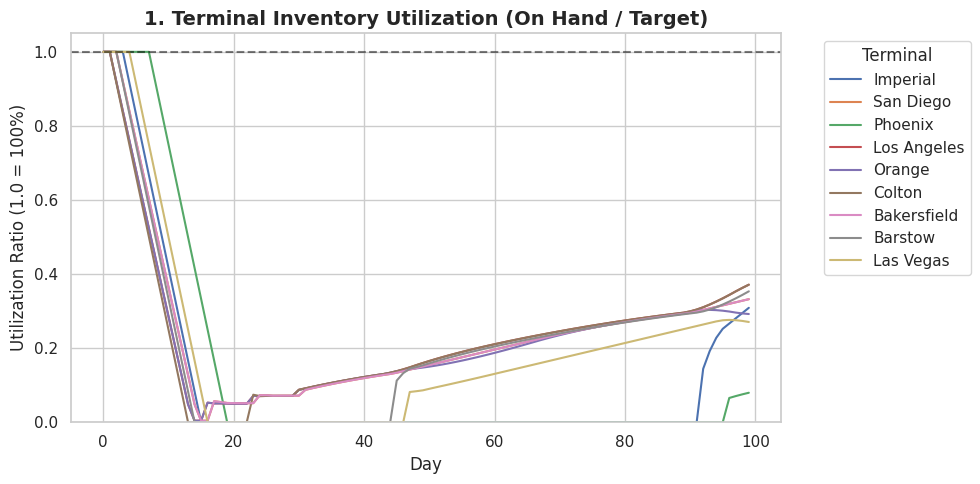

In [428]:
# Set the global visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

# Calculate utilization
df_term['inventory_utilization'] = df_term['on_hand_end'] / df_term['target_capacity']

# Plot
sns.lineplot(data=df_term, x='day', y='inventory_utilization', hue='terminal')
plt.title('1. Terminal Inventory Utilization (On Hand / Target)', fontsize=14, fontweight='bold')
plt.ylabel('Utilization Ratio (1.0 = 100%)')
plt.xlabel('Day')

plt.ylim(0.0, 1.05)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5) # Reference line
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Terminal")
plt.tight_layout()
plt.show()

##Terminal percent of normal demand satisfied

/tmp/ipykernel_1202/4122503037.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['demand_satisfied_pct'] = (df_filtered['satisfied'] / df_filtered['demand']) * 100


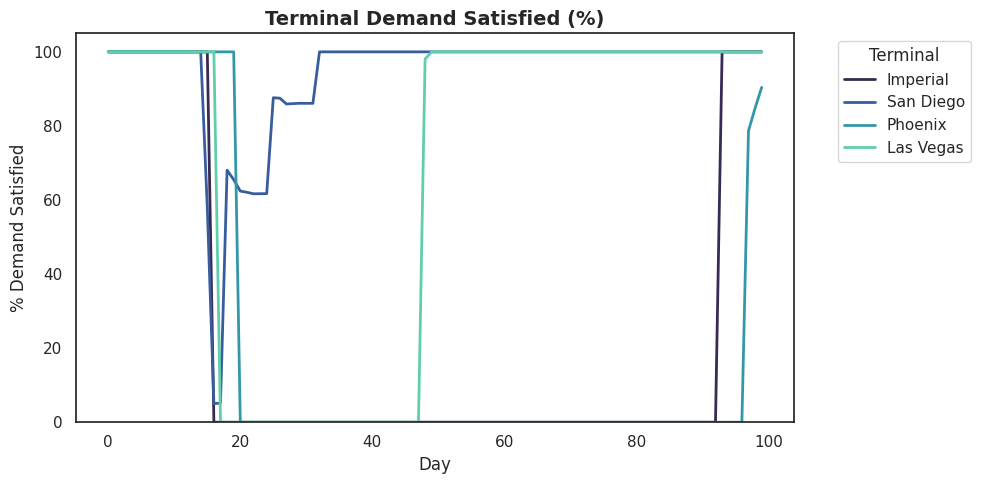

In [429]:
plt.figure(figsize=(10, 5))

terminals_to_show = ['Phoenix', 'Imperial', 'San Diego', 'Las Vegas']
df_filtered = df_term.loc[df_term['terminal'].isin(terminals_to_show)]

# Calculate percentage of demand satisfied

df_filtered['demand_satisfied_pct'] = (df_filtered['satisfied'] / df_filtered['demand']) * 100

# Plot
sns.set_theme(style="white")
sns.lineplot(data=df_filtered, x='day', y='demand_satisfied_pct', hue='terminal', palette = 'mako',linewidth = 2)
plt.title('Terminal Demand Satisfied (%)', fontsize=14, fontweight='bold')
plt.ylabel('% Demand Satisfied')
plt.xlabel('Day')
plt.ylim(0, 105) # Cap at 100% for readability
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Terminal")
plt.tight_layout()
plt.show()

##Refinery Utilization

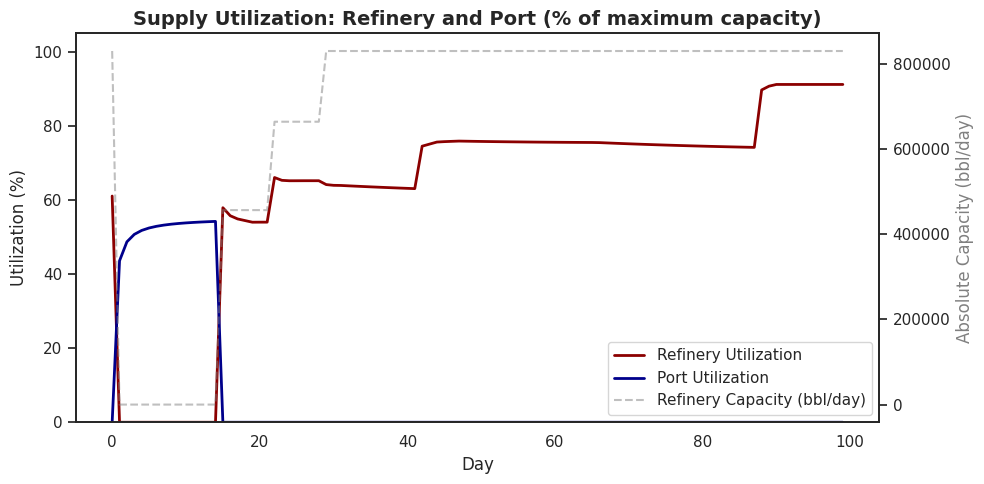

In [430]:
fig, ax = plt.subplots(figsize=(10, 5))

# 1. Convert to percentages
df_ref['utilization_pct'] = df_ref['refinery_utilization'] * 100
df_port['utilization_pct'] = df_port['port_utilization'] * 100

# 2. Plot Utilizations (Primary Y-Axis)
sns.lineplot(data=df_ref, x='day', y='utilization_pct', color='darkred', linewidth=2, label='Refinery Utilization', ax=ax)
sns.lineplot(data=df_port, x='day', y='utilization_pct', color='darkblue', linewidth=2, label='Port Utilization', ax=ax)

# 3. Plot Absolute Capacity (Secondary Y-Axis)
ax2 = ax.twinx()
sns.lineplot(data=df_ref, x='day', y='refinery_capacity', color='grey', linestyle='--', alpha=0.5, label='Refinery Capacity (bbl/day)', ax=ax2)

# Formatting
ax.set_title('Supply Utilization: Refinery and Port (% of maximum capacity)', fontsize=14, fontweight='bold')
ax.set_ylabel('Utilization (%)')
ax2.set_ylabel('Absolute Capacity (bbl/day)', color='grey')
ax.set_xlabel('Day')
ax.set_ylim(0, 105)

# --- NEW LEGEND LOGIC ---
# Extract lines and labels from BOTH axes
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine them into a single legend on the primary axis in the bottom right ('lower right')
ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

# Remove the automatic secondary legend so it doesn't print twice
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
# ------------------------

plt.tight_layout()
plt.show()

##Pipeline Utilization

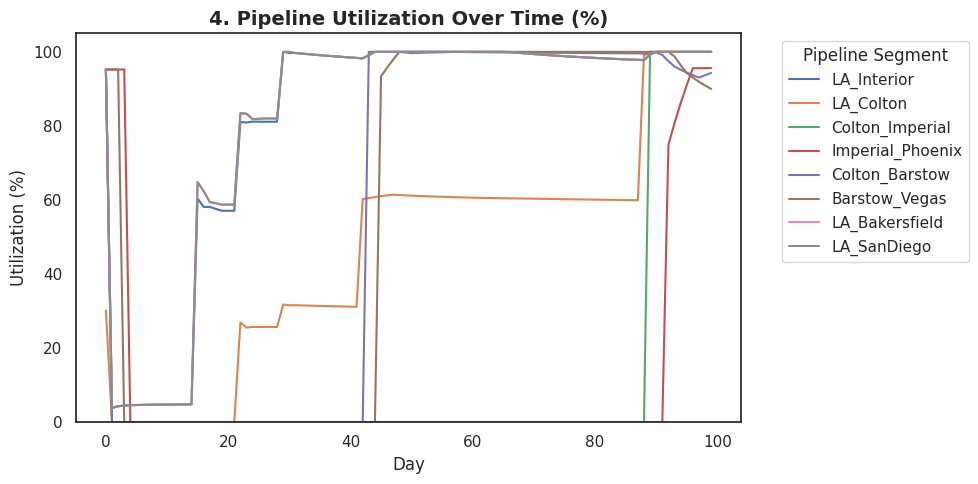

In [431]:
plt.figure(figsize=(10, 5))

# Convert to percentage
df_pipe['utilization_pct'] = df_pipe['utilization'] * 100

# Plot
sns.lineplot(data=df_pipe, x='day', y='utilization_pct', hue='pipeline')
plt.title('4. Pipeline Utilization Over Time (%)', fontsize=14, fontweight='bold')
plt.ylabel('Utilization (%)')
plt.xlabel('Day')
plt.ylim(0, 105)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Pipeline Segment")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1202/1268511293.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.axes[0].legend(loc='upper right')


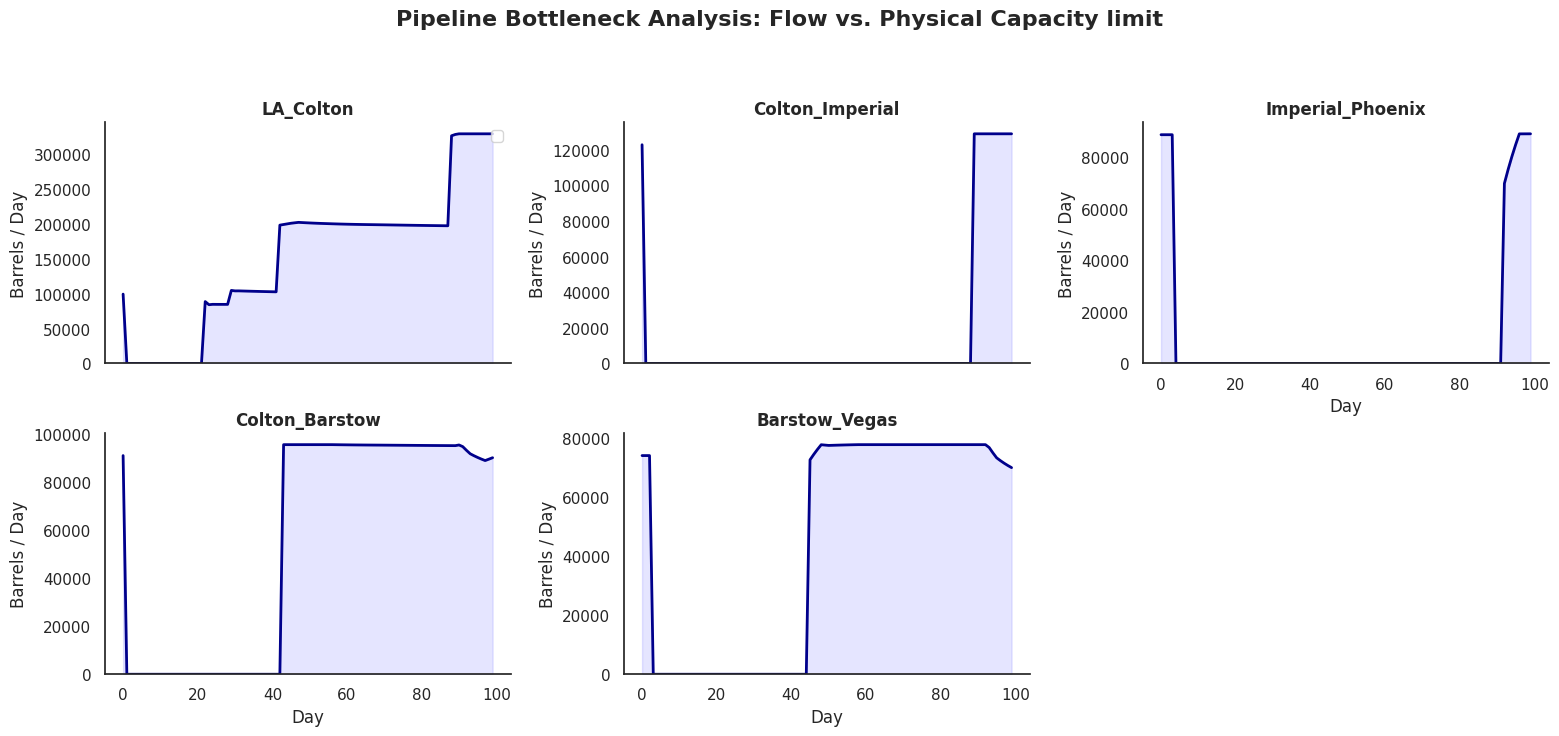

In [432]:
# 1. Create a grid of charts for every single pipeline
pipelines_to_show = ['LA_Colton', 'Colton_Imperial','Imperial_Phoenix','Colton_Barstow','Barstow_Vegas']
df_pipe_filtered = df_pipe.loc[df_pipe['pipeline'].isin(pipelines_to_show)]
g = sns.relplot(
    data=df_pipe_filtered,
    x='day',
    y='used_today',
    col='pipeline',
    col_wrap=3,
    kind='line',
    height=3.5,
    aspect=1.5,
    color='darkblue',
    linewidth=2,
    facet_kws={'sharey': False} # <--- THIS FIXES THE RED LINES
)

# 2. Loop through each mini-chart to add the Capacity limits and shading
for ax, pipeline_name in zip(g.axes.flat, g.col_names):
    subset = df_pipe_filtered[df_pipe_filtered['pipeline'] == pipeline_name]

    # Draw the Red Dashed Line
    #ax.plot(subset['day'], subset['cap'], color='red', linestyle='--', linewidth=2, label='Max Capacity')

    # Fill the blue area
    ax.fill_between(subset['day'], subset['used_today'], color='blue', alpha=0.1)

    # Formatting
    ax.set_title(pipeline_name, fontweight='bold')
    ax.set_ylabel('Barrels / Day')
    ax.set_xlabel('Day')
    ax.set_ylim(bottom=0)

plt.suptitle('Pipeline Bottleneck Analysis: Flow vs. Physical Capacity limit', y=1.05, fontsize=16, fontweight='bold')
g.axes[0].legend(loc='upper right')

plt.tight_layout()
plt.show()

##Total System Throughput demand as pctg, vs inventory as pctg

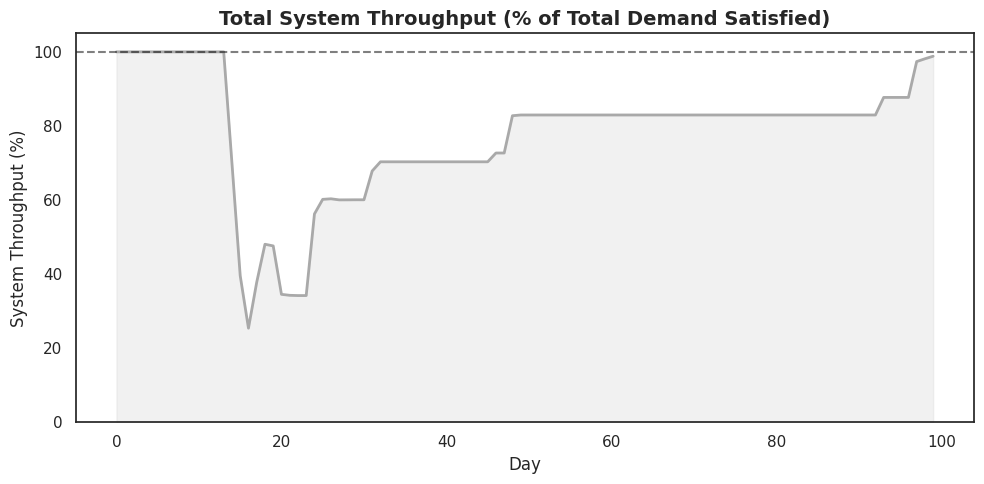

In [433]:
plt.figure(figsize=(10, 5))

# Group by day and sum the satisfied demand and total baseline demand
df_throughput = df_term.groupby('day')[['satisfied', 'demand']].sum().reset_index()

# Calculate system throughput as a percentage of the total demand
df_throughput['throughput_pct'] = (df_throughput['satisfied'] / df_throughput['demand']) * 100

# Plot as an area/line chart
sns.lineplot(data=df_throughput, x='day', y='throughput_pct', color='darkgrey', linewidth=2)
plt.fill_between(df_throughput['day'], df_throughput['throughput_pct'], color='lightgrey', alpha=0.3)

plt.title('Total System Throughput (% of Total Demand Satisfied)', fontsize=14, fontweight='bold')
plt.ylabel('System Throughput (%)')
plt.xlabel('Day')
plt.ylim(0, 105) # Cap at slightly above 100% for readability
plt.axhline(100, color='black', linestyle='--', alpha=0.5) # Reference line for 100%

plt.tight_layout()
plt.show()

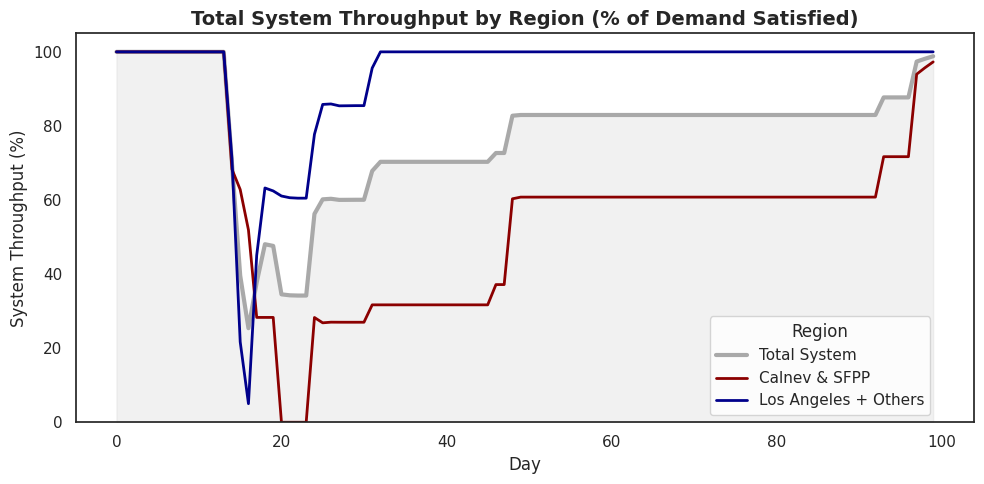

In [434]:
plt.figure(figsize=(10, 5))

# 1. Define the terminal groups
group_calnev = ['Colton', 'Barstow', 'Las Vegas', 'Imperial', 'Phoenix']
group_la = ['Los Angeles', 'San Diego', 'Bakersfield', 'Orange']

# 2. Calculate Total System Throughput
df_total = df_term.groupby('day')[['satisfied', 'demand']].sum().reset_index()
df_total['throughput_pct'] = (df_total['satisfied'] / df_total['demand']) * 100

# 3. Calculate Calnev & SFPP Group Throughput
df_calnev = df_term[df_term['terminal'].isin(group_calnev)].groupby('day')[['satisfied', 'demand']].sum().reset_index()
df_calnev['throughput_pct'] = (df_calnev['satisfied'] / df_calnev['demand']) * 100

# 4. Calculate Los Angeles + Others Group Throughput
df_la = df_term[df_term['terminal'].isin(group_la)].groupby('day')[['satisfied', 'demand']].sum().reset_index()
df_la['throughput_pct'] = (df_la['satisfied'] / df_la['demand']) * 100

# 5. Plot Total System (Thick line with shaded area)
plt.plot(df_total['day'], df_total['throughput_pct'], color='darkgrey', linewidth=3, label='Total System')
plt.fill_between(df_total['day'], df_total['throughput_pct'], color='lightgrey', alpha=0.3)

# 6. Plot the Regional Groups
plt.plot(df_calnev['day'], df_calnev['throughput_pct'], color='darkred', linewidth=2, label='Calnev & SFPP')
plt.plot(df_la['day'], df_la['throughput_pct'], color='darkblue', linewidth=2, label='Los Angeles + Others')

# 7. Formatting
plt.title('Total System Throughput by Region (% of Demand Satisfied)', fontsize=14, fontweight='bold')
plt.ylabel('System Throughput (%)')
plt.xlabel('Day')
plt.ylim(0, 105) # Cap at slightly above 100% for readability
#plt.axhline(100, color='black', linestyle='--', alpha=0.5) # Reference line for 100%

# Place the legend neatly outside the chart
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Region")

#plt.legend(loc='lower right', title="Region")
plt.legend(loc='lower right', bbox_to_anchor=(0.96, 0.0), title="Region")
plt.tight_layout()
plt.show()

###Saving Scenario

In [435]:

df_term['scenario']='scenario_to_save'
df_term.to_csv('scenario_to_save.csv')

In [436]:
# 1. Define the terminal groups
group_calnev = ['Colton', 'Barstow', 'Las Vegas', 'Imperial', 'Phoenix']
group_la = ['Los Angeles', 'San Diego', 'Bakersfield', 'Orange']

# 2. Filter the data for exactly Day 0 to Day 100
df_window = df_term[(df_term['day'] >=0) & (df_term['day'] <= 40)]

# 3. Calculate metrics for the Total System
total_demand = df_window['demand'].sum()
total_satisfied = df_window['satisfied'].sum()

# 4. Calculate metrics for Calnev & SFPP
df_calnev = df_window[df_window['terminal'].isin(group_calnev)]
calnev_demand = df_calnev['demand'].sum()
calnev_satisfied = df_calnev['satisfied'].sum()

# 5. Calculate metrics for Los Angeles + Others
df_la = df_window[df_window['terminal'].isin(group_la)]
la_demand = df_la['demand'].sum()
la_satisfied = df_la['satisfied'].sum()

# 6. Build the Summary DataFrame
summary_data = [
    {
        'Region Group': 'Total System',
        'Total Demand': total_demand,
        'Total Satisfied': total_satisfied,
        'Overall Throughput (%)': (total_satisfied / total_demand) * 100 if total_demand > 0 else 0
    },
    {
        'Region Group': 'Calnev & SFPP',
        'Total Demand': calnev_demand,
        'Total Satisfied': calnev_satisfied,
        'Overall Throughput (%)': (calnev_satisfied / calnev_demand) * 100 if calnev_demand > 0 else 0
    },
    {
        'Region Group': 'Los Angeles + Others',
        'Total Demand': la_demand,
        'Total Satisfied': la_satisfied,
        'Overall Throughput (%)': (la_satisfied / la_demand) * 100 if la_demand > 0 else 0
    }
]

df_throughput_summary = pd.DataFrame(summary_data)

# Round the percentage to 2 decimal places so it looks clean
df_throughput_summary['Overall Throughput (%)'] = df_throughput_summary['Overall Throughput (%)'].round(2)

# Display the beautiful table!
display(df_throughput_summary)

,Region Group,Total Demand,Total Satisfied,Overall Throughput (%)
0,Total System,29560733.5,2.107615e+07,71.30
1,Calnev & SFPP,12847493.5,6.815651e+06,53.05
2,Los Angeles + Others,16713240.0,1.426050e+07,85.32


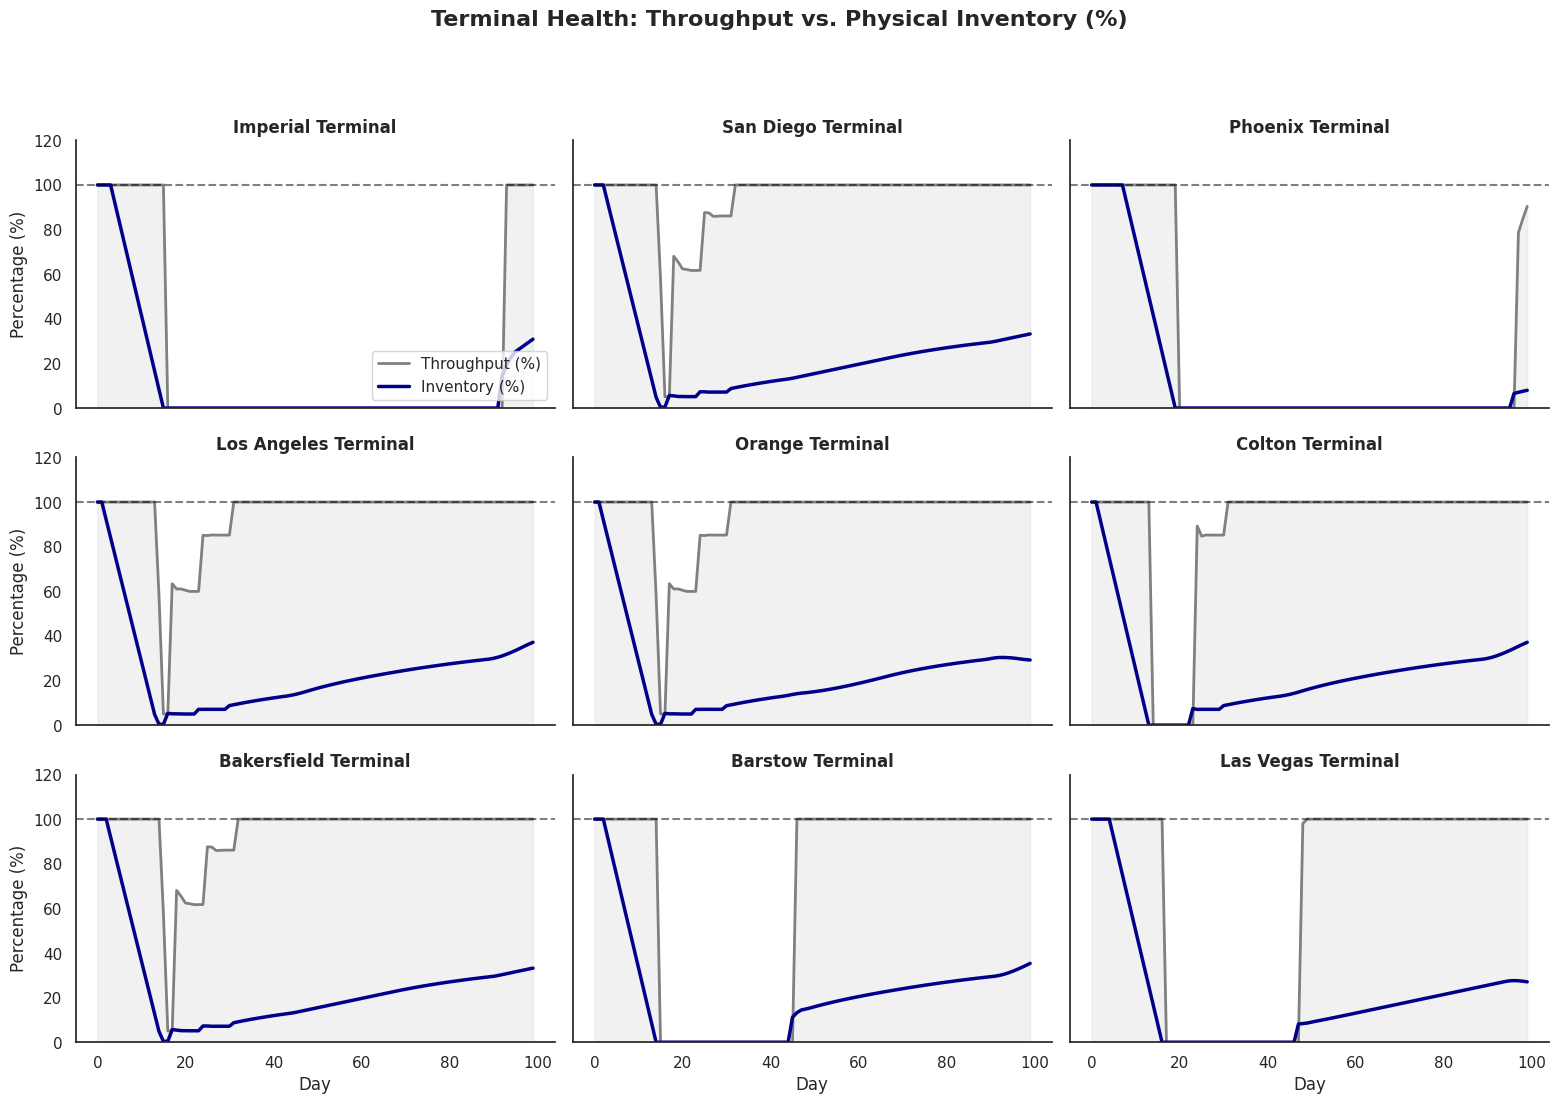

In [437]:
# 1. Calculate both metrics as percentages
df_term['throughput_pct'] = (df_term['satisfied'] / df_term['demand']) * 100
df_term['inventory_pct'] = (df_term['on_hand_end'] / df_term['target_capacity']) * 100

# 2. Create the base grid using Throughput
g = sns.relplot(
    data=df_term,
    x='day',
    y='throughput_pct',
    col='terminal',
    col_wrap=3,
    kind='line',
    height=3.5,
    aspect=1.5,
    color='grey',
    linewidth=2,
    label='Throughput (%)'
)

# 3. Loop through each mini-chart to add the Inventory line, shading, and formatting
for ax, terminal_name in zip(g.axes.flat, g.col_names):
    # Filter data for this specific mini-chart
    subset = df_term[df_term['terminal'] == terminal_name]

    # Fill the area under the Throughput curve (Green)
    ax.fill_between(subset['day'], subset['throughput_pct'], color='lightgrey', alpha=0.3)

    # NEW: Plot the Inventory Utilization line (Orange)
    ax.plot(subset['day'], subset['inventory_pct'], color='darkblue', linewidth=2.5, label='Inventory (%)')

    # Formatting
    ax.set_title(f'{terminal_name} Terminal', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Day')

    # Bumped the y-limit to 120 so the 105% inventory "catch-up" spikes fit perfectly
    ax.set_ylim(0, 120)

    # Reference line for the 100% target
    ax.axhline(100, color='black', linestyle='--', alpha=0.5)

# Add a master title and a combined legend
plt.suptitle('Terminal Health: Throughput vs. Physical Inventory (%)', y=1.05, fontsize=16, fontweight='bold')

# Put the legend in a spot where it won't block the drop
g.axes[0].legend(loc='lower right')

plt.tight_layout()
plt.show()

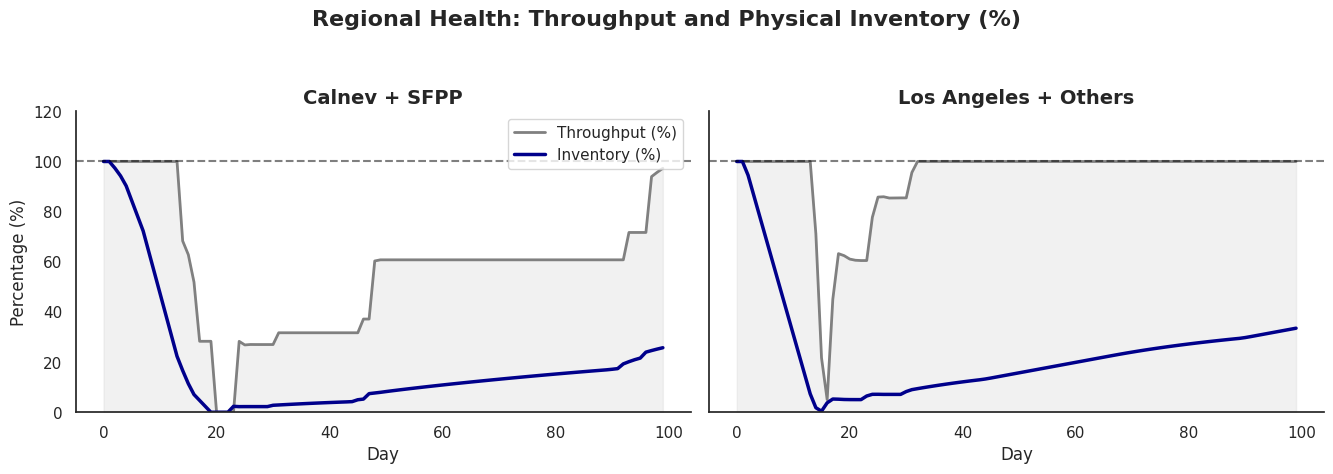

In [453]:
# 1. Define the regional groups
group_calnev = ['Colton', 'Barstow', 'Las Vegas', 'Imperial', 'Phoenix']
group_la = ['Los Angeles', 'San Diego', 'Bakersfield', 'Orange']

# 2. Map terminals to groups and aggregate the raw data
def assign_region(terminal):
    if terminal in group_calnev:
        return 'Calnev + SFPP'
    elif terminal in group_la:
        return 'Los Angeles + Others'
    return 'Other'

df_term['region_group'] = df_term['terminal'].apply(assign_region)

# Aggregate by day and region (summing volumes first to get accurate weighted averages)
df_regional = df_term.groupby(['day', 'region_group'])[['satisfied', 'demand', 'on_hand_end', 'target_capacity']].sum().reset_index()

# 3. Calculate aggregate percentages for the groups
df_regional['throughput_pct'] = (df_regional['satisfied'] / df_regional['demand']) * 100
df_regional['inventory_pct'] = (df_regional['on_hand_end'] / df_regional['target_capacity']) * 100

# 4. Create the grid for the two groups
g = sns.relplot(
    data=df_regional,
    x='day',
    y='throughput_pct',
    col='region_group',
    col_wrap=2,
    kind='line',
    height=4.5,
    aspect=1.5,
    color='grey',
    linewidth=2,
    label='Throughput (%)'
)

# 5. Apply the specific styling from cell 437
for ax, region_name in zip(g.axes.flat, g.col_names):
    # Filter data for this specific region
    subset = df_regional[df_regional['region_group'] == region_name]

    # Fill the area under the Throughput curve (Grey)
    ax.fill_between(subset['day'], subset['throughput_pct'], color='lightgrey', alpha=0.3)

    # Plot the Inventory Utilization line (Dark Blue)
    ax.plot(subset['day'], subset['inventory_pct'], color='darkblue', linewidth=2.5, label='Inventory (%)')

    # Formatting
    ax.set_title(region_name, fontweight='bold', fontsize=14)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Day')
    ax.set_ylim(0, 120)

    # Reference line for the 100% target
    ax.axhline(100, color='black', linestyle='--', alpha=0.5)

# Add master title and legend
plt.suptitle('Regional Health: Throughput and Physical Inventory (%)', y=1.05, fontsize=16, fontweight='bold')
g.axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

##Throughput as % of injection capacity

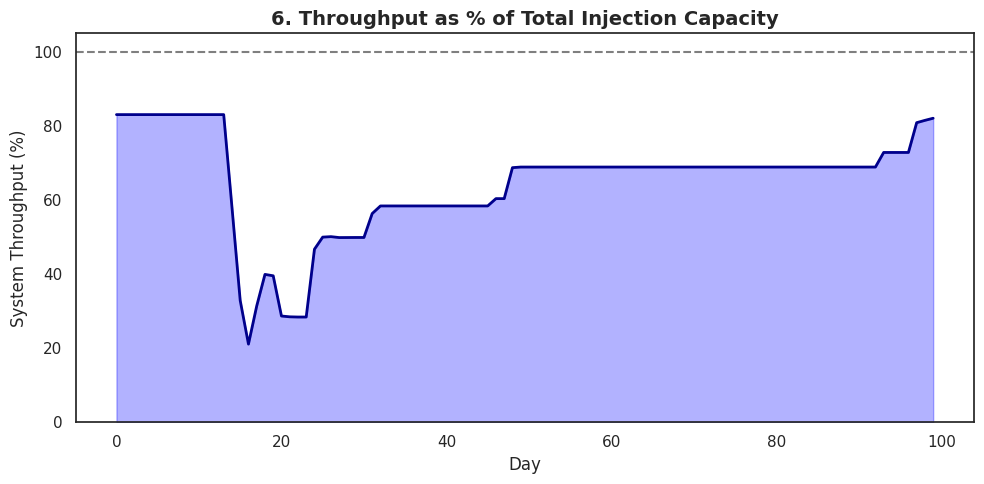

In [438]:
plt.figure(figsize=(10, 5))

# 1. Calculate the total baseline injection capacity from df_supply
ref_base_cap = float(df_supply[df_supply['supply_type'] == 'refinery']['capacity_bbl_day'].values[0])
port_cap = float(df_supply[df_supply['supply_type'] == 'port']['capacity_bbl_day'].values[0])
total_injection_capacity = ref_base_cap + port_cap

# 2. Group by day and sum the satisfied demand
df_throughput = df_term.groupby('day')['satisfied'].sum().reset_index()

# 3. Calculate system throughput as a percentage of the total injection capacity
df_throughput['throughput_pct'] = (df_throughput['satisfied'] / total_injection_capacity) * 100

# Plot as an area/line chart
sns.lineplot(data=df_throughput, x='day', y='throughput_pct', color='darkblue', linewidth=2)
plt.fill_between(df_throughput['day'], df_throughput['throughput_pct'], color='blue', alpha=0.3)

plt.title('6. Throughput as % of Total Injection Capacity', fontsize=14, fontweight='bold')
plt.ylabel('System Throughput (%)')
plt.xlabel('Day')
plt.ylim(0, 105)
plt.axhline(100, color='black', linestyle='--', alpha=0.5) # Reference line for Maximum Injection Capacity

plt.tight_layout()
plt.show()

In [439]:
df_term.loc[df_term['terminal']=='San Diego'].head(20)

,day,terminal,demand,target_capacity,satisfied,ordered,inj_refinery,inj_port,received,on_hand_end,in_transit_end,inventory_utilization,scenario,throughput_pct,inventory_pct
1,0,San Diego,65636.0,787632.0,65636.000000,65636.000000,65636.000000,0.000000,65636.000000,787632.000000,131272.000000,1.000000,scenario_to_save,100.000000,100.000000
10,1,San Diego,65636.0,787632.0,65636.000000,65636.000000,0.000000,2664.466712,0.000000,787632.000000,68300.466712,1.000000,scenario_to_save,100.000000,100.000000
19,2,San Diego,65636.0,787632.0,65636.000000,128607.533288,0.000000,2977.518109,65636.000000,787632.000000,5641.984822,1.000000,scenario_to_save,100.000000,100.000000
28,3,San Diego,65636.0,787632.0,65636.000000,191266.015178,0.000000,3099.901136,2664.466712,724660.466712,6077.419246,0.920050,scenario_to_save,100.000000,92.004955
37,4,San Diego,65636.0,787632.0,65636.000000,253802.114042,0.000000,3165.069660,2977.518109,662001.984822,6264.970797,0.840497,scenario_to_save,100.000000,84.049656
46,5,San Diego,65636.0,787632.0,65636.000000,316273.044382,0.000000,3205.504450,3099.901136,599465.885958,6370.574110,0.761099,scenario_to_save,100.000000,76.109895
55,6,San Diego,65636.0,787632.0,65636.000000,378703.539932,0.000000,3233.020959,3165.069660,536994.955618,6438.525409,0.681784,scenario_to_save,100.000000,68.178408
64,7,San Diego,65636.0,787632.0,65636.000000,441106.518973,0.000000,3252.946697,3205.504450,474564.460068,6485.967656,0.602521,scenario_to_save,100.000000,60.252054
73,8,San Diego,65636.0,787632.0,65636.000000,503489.572276,0.000000,3268.035816,3233.020959,412161.481027,6520.982513,0.523292,scenario_to_save,100.000000,52.329194
82,9,San Diego,65636.0,787632.0,65636.000000,565857.536460,0.000000,3279.854940,3252.946697,349778.427724,6547.890756,0.444089,scenario_to_save,100.000000,44.408865


#Different scenarios joined together

In [440]:
baseline_disruption=pd.read_csv('/content/baseline.csv')
baseline_with_lever=pd.read_csv('/content/baseline with lever.csv')
baseline_disruption_without_phillips66=pd.read_csv('/content/baseline wo p66.csv')
baseline_disruption_without_phillips66_plus_lever=pd.read_csv('/content/baseline wo p66 + lever.csv')

In [441]:
baseline_disruption.head()

,Unnamed: 0,day,terminal,demand,target_capacity,satisfied,ordered,inj_refinery,inj_port,received,on_hand_end,in_transit_end,inventory_utilization,scenario
0,0,0,Imperial,34200.0,410400.0,34200.0,34200.0,34200.0,0.0,34200.0,410400.0,136800.0,1.0,scenario_to_save
1,1,0,San Diego,65636.0,787632.0,65636.0,65636.0,65636.0,0.0,65636.0,787632.0,131272.0,1.0,scenario_to_save
2,2,0,Phoenix,88684.5,1064214.0,88684.5,88684.5,88684.5,0.0,88684.5,1064214.0,709476.0,1.0,scenario_to_save
3,3,0,Los Angeles,155957.0,1871484.0,155957.0,155957.0,155957.0,0.0,155957.0,1871484.0,155957.0,1.0,scenario_to_save
4,4,0,Orange,123373.0,1480476.0,123373.0,123373.0,123373.0,0.0,123373.0,1480476.0,123373.0,1.0,scenario_to_save


In [442]:
baseline_with_lever

,Unnamed: 0,day,terminal,demand,target_capacity,satisfied,ordered,inj_refinery,inj_port,received,on_hand_end,in_transit_end,inventory_utilization,scenario
0,0,0,Imperial,34200.0,410400.0,34200.0,34200.000000,34200.000000,0.0,34200.000000,4.104000e+05,136800.000000,1.000000,scenario_to_save
1,1,0,San Diego,65636.0,787632.0,65636.0,65636.000000,65636.000000,0.0,65636.000000,7.876320e+05,131272.000000,1.000000,scenario_to_save
2,2,0,Phoenix,88684.5,1064214.0,88684.5,88684.500000,88684.500000,0.0,88684.500000,1.064214e+06,709476.000000,1.000000,scenario_to_save
3,3,0,Los Angeles,155957.0,1871484.0,155957.0,155957.000000,155957.000000,0.0,155957.000000,1.871484e+06,155957.000000,1.000000,scenario_to_save
4,4,0,Orange,123373.0,1480476.0,123373.0,123373.000000,123373.000000,0.0,123373.000000,1.480476e+06,123373.000000,1.000000,scenario_to_save
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,99,Orange,123373.0,1480476.0,123373.0,688814.760086,137554.590194,0.0,137553.391061,9.150342e+05,137554.590194,0.618068,scenario_to_save
896,896,99,Colton,99321.0,1191852.0,99321.0,459551.965194,108078.566338,0.0,108079.330004,8.316210e+05,108078.566338,0.697755,scenario_to_save
897,897,99,Bakersfield,62674.0,752088.0,62674.0,315619.381242,68941.400000,0.0,68941.400000,4.928752e+05,137882.800000,0.655342,scenario_to_save
898,898,99,Barstow,17151.0,205812.0,17151.0,79356.580488,18663.276622,0.0,18663.745200,1.405814e+05,55990.247512,0.683058,scenario_to_save


In [443]:
baseline_disruption_without_phillips66.head()

,Unnamed: 0,day,terminal,demand,target_capacity,satisfied,ordered,inj_refinery,inj_port,received,on_hand_end,in_transit_end,inventory_utilization,scenario
0,0,0,Imperial,34200.0,410400.0,34200.0,34200.0,34200.0,0.0,34200.0,410400.0,136800.0,1.0,scenario_to_save
1,1,0,San Diego,65636.0,787632.0,65636.0,65636.0,65636.0,0.0,65636.0,787632.0,131272.0,1.0,scenario_to_save
2,2,0,Phoenix,88684.5,1064214.0,88684.5,88684.5,88684.5,0.0,88684.5,1064214.0,709476.0,1.0,scenario_to_save
3,3,0,Los Angeles,155957.0,1871484.0,155957.0,155957.0,155957.0,0.0,155957.0,1871484.0,155957.0,1.0,scenario_to_save
4,4,0,Orange,123373.0,1480476.0,123373.0,123373.0,123373.0,0.0,123373.0,1480476.0,123373.0,1.0,scenario_to_save


In [444]:
baseline_disruption_without_phillips66_plus_lever.head()

,Unnamed: 0,day,terminal,demand,target_capacity,satisfied,ordered,inj_refinery,inj_port,received,on_hand_end,in_transit_end,inventory_utilization,scenario
0,0,0,Imperial,34200.0,410400.0,34200.0,34200.0,34200.0,0.0,34200.0,410400.0,136800.0,1.0,scenario_to_save
1,1,0,San Diego,65636.0,787632.0,65636.0,65636.0,65636.0,0.0,65636.0,787632.0,131272.0,1.0,scenario_to_save
2,2,0,Phoenix,88684.5,1064214.0,88684.5,88684.5,88684.5,0.0,88684.5,1064214.0,709476.0,1.0,scenario_to_save
3,3,0,Los Angeles,155957.0,1871484.0,155957.0,155957.0,155957.0,0.0,155957.0,1871484.0,155957.0,1.0,scenario_to_save
4,4,0,Orange,123373.0,1480476.0,123373.0,123373.0,123373.0,0.0,123373.0,1480476.0,123373.0,1.0,scenario_to_save


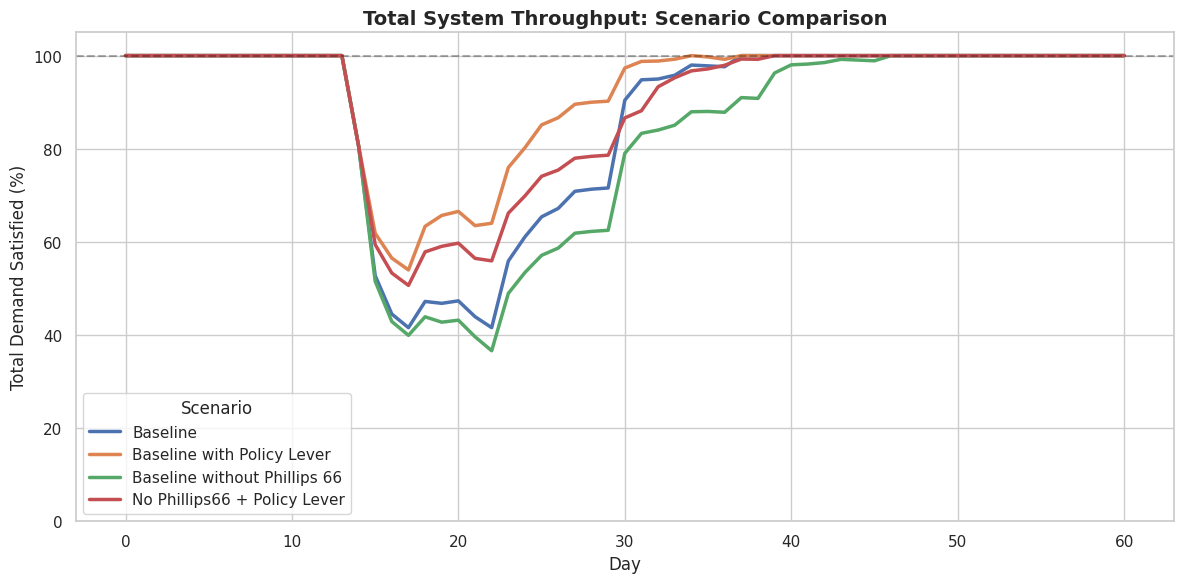

In [445]:
# 1. Helper function to calculate aggregate system throughput %
def calculate_system_throughput(df, label):
    # Group by day and sum system-wide totals
    thru = df.groupby('day')[['satisfied', 'demand']].sum().reset_index()
    thru['throughput_pct'] = (thru['satisfied'] / thru['demand']) * 100
    thru['Scenario'] = label
    return thru

# 2. Process the three DataFrames loaded in cell 102
# (Using the variables you defined: baseline_disruption, etc.)
t1 = calculate_system_throughput(baseline_disruption, 'Baseline')
t2 = calculate_system_throughput(baseline_with_lever, 'Baseline with Policy Lever')
t3 = calculate_system_throughput(baseline_disruption_without_phillips66, 'Baseline without Phillips 66')
t4 = calculate_system_throughput(baseline_disruption_without_phillips66_plus_lever, 'No Phillips66 + Policy Lever')

# 3. Combine for plotting
df_comparison = pd.concat([t1, t2, t3, t4])
df_comparison = df_comparison[df_comparison['day']<=60]

# 4. Create the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df_comparison, x='day', y='throughput_pct', hue='Scenario', linewidth=2.5)

# Formatting
plt.title('Total System Throughput: Scenario Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Total Demand Satisfied (%)')
plt.xlabel('Day')
plt.ylim(0, 105)
plt.axhline(100, color='black', linestyle='--', alpha=0.3) # Reference line at 100%
plt.legend(title="Scenario", loc='lower left')

plt.tight_layout()
plt.show()

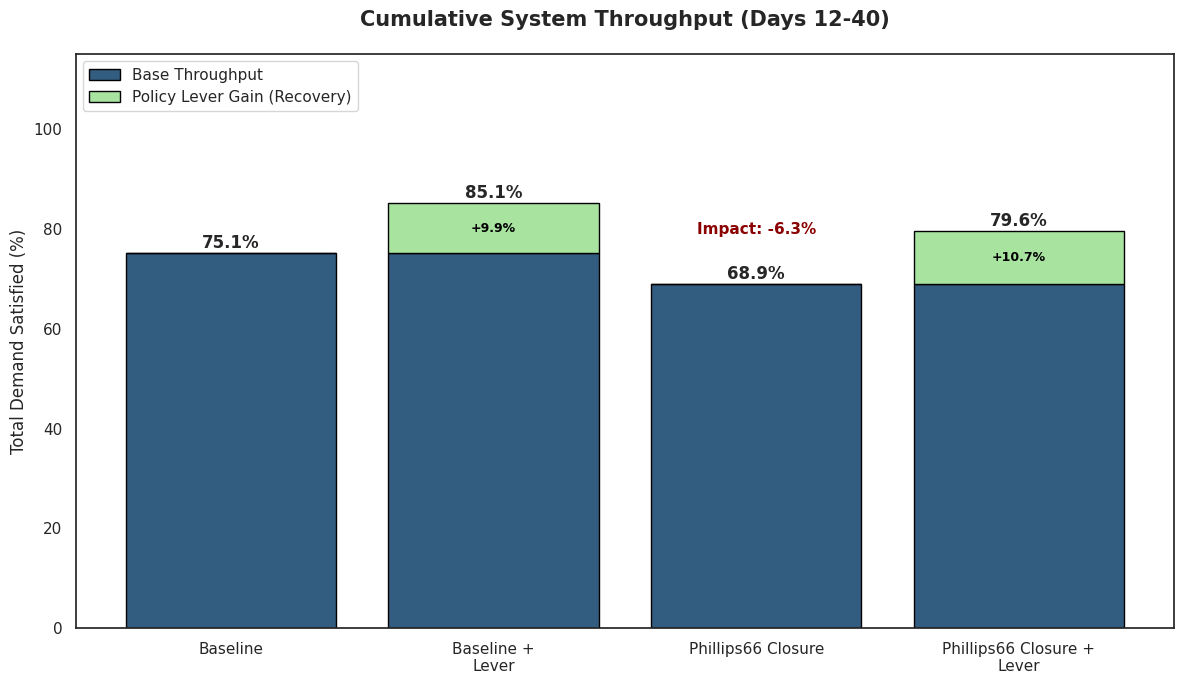

In [446]:
# 1. Helper to calculate cumulative throughput % from Day 12 to Day 40
def get_total_throughput_pct(df, start_day=12, end_day=40):
    window = df[(df['day'] >= start_day) & (df['day'] <= end_day)]
    total_demand = window['demand'].sum()
    total_satisfied = window['satisfied'].sum()
    return (total_satisfied / total_demand) * 100 if total_demand > 0 else 0

# 2. Extract values
v_base = get_total_throughput_pct(baseline_disruption)
v_lever = get_total_throughput_pct(baseline_with_lever)
v_no_p66 = get_total_throughput_pct(baseline_disruption_without_phillips66)
v_no_p66_lever = get_total_throughput_pct(baseline_disruption_without_phillips66_plus_lever)

# 3. Define the "Bottom" and "Top" (Delta) portions
base_parts = [v_base, v_base, v_no_p66, v_no_p66]
delta_parts = [0, v_lever - v_base, 0, v_no_p66_lever - v_no_p66]

labels = ['Baseline', 'Baseline +\nLever', 'Phillips66 Closure', 'Phillips66 Closure +\nLever']
color_main = '#335C81'   # Darker Blue
color_delta = '#A8E4A0'  # Light Green for Recovery

plt.figure(figsize=(12, 7))
sns.set_theme(style="white") # Changed to "white" to remove the background grid

# Plot the base parts (Dark Blue)
plt.bar(labels, base_parts, color=color_main, edgecolor='black', label='Base Throughput')

# Plot the delta parts on top (Light Green)
plt.bar(labels, delta_parts, bottom=base_parts, color=color_delta,
        edgecolor='black', label='Policy Lever Gain (Recovery)')

# 4. Add Numeric Labels
for i in range(len(labels)):
    total = base_parts[i] + delta_parts[i]
    plt.text(i, total + 1, f'{total:.1f}%', ha='center', fontweight='bold')

    if delta_parts[i] > 0:
        plt.text(i, base_parts[i] + (delta_parts[i]/2), f"+{delta_parts[i]:.1f}%",
                 ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# 5. Impact Label (Text only, no arrow)
plt.text(2, v_no_p66 + 10, f'Impact: -{v_base - v_no_p66:.1f}%',
         ha='center', fontweight='bold', color='darkred', fontsize=11)

# Formatting
plt.title('Cumulative System Throughput (Days 12-40)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Total Demand Satisfied (%)')
plt.ylim(0, 115)
plt.legend(loc='upper left')
# plt.grid line removed entirely
plt.tight_layout()

plt.show()